In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm
from pymodulon.io import *
from pymodulon.compare import *
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import pickle


pd.set_option('display.max_columns', 100, 'display.max_rows', 100)

In [2]:
# Editing text on PDF:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')

## Figure 4A

In [4]:
############### output already stored in dima_counts.pkl


# dimas_counts = {}
# for proj in tqdm(np.unique(ica_data.sample_table.project.values)):
#     for condition, group in tqdm(ica_data.sample_table.loc[ica_data.sample_table.project == proj].groupby('condition')):
#         ref = np.unique(ica_data.sample_table.loc[ica_data.sample_table.project == proj].reference_condition.values)[0].split(';')
#         samp1 = group.index.values
#         plot, table = plot_dima(ica_data, ref, samp1, table = True)
#         k = proj + ':' + condition
#         dimas_counts[k] = table.shape[0]

In [5]:
with open('C:\\Users\\99hee\\precise_mg1655\\5_characterize_iModulons\\dima_counts.pkl', 'rb') as file:
    dima_counts = pickle.load(file)

In [6]:
dima_counts

{'CFP:WT': 2,
 'INDIMOD:LiAcet': 17,
 'INDIMOD:M9_glucose': 0,
 'INDIMOD:TB': 44,
 'INDIMOD:acetate': 23,
 'INDIMOD:anaerobic': 57,
 'INDIMOD:paraquat': 34,
 'INDIMOD:sorbital_arginine': 13,
 'INDIMOD:stationary': 22,
 'RPO:wt': 0,
 'RPO:wt_42C': 1,
 'RPO:wt_methionine': 1,
 'RPO:wt_octanoic': 3,
 'SNPv1:Adenosine_NH4Cl': 26,
 'SNPv1:Cytidine_NH4Cl': 13,
 'SNPv1:D-Alanine_NH4Cl': 37,
 'SNPv1:D-Galactose_NH4Cl': 18,
 'SNPv1:D-Galacturonic_acid_NH4Cl': 12,
 'SNPv1:D-Gluconic_acid_NH4Cl': 1,
 'SNPv1:D-Glucosamine_NH4Cl': 21,
 'SNPv1:D-Glucose-6-Phosphate_NH4Cl': 23,
 'SNPv1:D-Glucose_NH4Cl': 0,
 'SNPv1:D-Glucuronic_acid_NH4Cl': 20,
 'SNPv1:D-Malic_acid_NH4Cl': 26,
 'SNPv1:D-Mannitol_NH4Cl': 2,
 'SNPv1:D-Mannose_NH4Cl': 11,
 'SNPv1:D-Melibiose_NH4Cl': 1,
 'SNPv1:D-Saccharic_acid_NH4Cl': 8,
 'SNPv1:D-Serine_NH4Cl': 31,
 'SNPv1:D-Sorbitol_NH4Cl': 15,
 'SNPv1:D-Trehalose_NH4Cl': 11,
 'SNPv1:DL-Malic_acid_NH4Cl': 32,
 'SNPv1:Dulcitol_NH4Cl': 24,
 'SNPv1:Glucose_Adenine': 21,
 'SNPv1:Glucose_Ad

In [7]:
#### projects with an in-project control that was used for normalization 
####(all projects except single condition projects and misc projects)
#### only including these for dima counts plot

projects_of_interest = ['INDIMOD', 'RPO', 'SNPv1', 'SNPv2', 'TRN', 'abx_media', 'antibiotICA',
                       'cra_crp', 'ddb_pd_038', 'electric_coli', 'fur', 'ica', 'minspan', 'nac_ntrc',
                       'omics', 'oxyR', 'tcs', 'ytf', 'ytf3', 'ytf5']

In [8]:
# all reference conditions -- we want to remove these (dimas of ref vs ref results)
ref_conds = []

# reference conditions in "x;y" format
ref_ids = np.unique(ica_data.sample_table.reference_condition.values)

for el in ref_ids:
    # change to [x,y] format
    _id = el.split(';')
    # change to project:condition format to match dictionary -- all elements with _id should have the same project:condition
    new_id = ica_data.sample_table.loc[_id[0], 'project'] + ':' + ica_data.sample_table.loc[_id[0], 'condition']
    ref_conds.append(new_id)
    
ref_conds

['SNPv2:Glucose_NH4Cl',
 'RPO:wt',
 'TRN:stationary_C_3h',
 'abx_media:m9_ctrl',
 'INDIMOD:M9_glucose',
 'antibiotICA:amp_1_16_t0',
 'control:wt_glc',
 'cra_crp:wt_ac',
 'ddb_pd_038:[DDB_PD_038]_[SDT122_WT]_[Batch]_[0h]',
 'electric_coli:biodesign_dmso',
 'fur:wt_fe',
 'ica:wt_glc',
 'minspan:wt_glc',
 'nac_ntrc:wt_csn',
 'omics:wt_glu',
 'oxyR:wt_glc',
 'tcs:wt_m9p',
 'ytf:wt_glc',
 'ytf3:wt_glc2',
 'ytf5:wt_glc',
 'SNPv1:D-Glucose_NH4Cl']

In [9]:
filtered_dima_counts = {}

for k,v in dima_counts.items():
    # removing reference conditions
    if k not in ref_conds:
        # removing unwanted projects
        proj = k.partition(':')[0]
        if proj in projects_of_interest:
            filtered_dima_counts[k] = v 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(21.0, 30, 'Median DiMAs = 18')

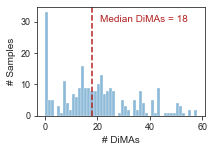

In [10]:
sns.set_style('ticks')

_, ax = plt.subplots(figsize=(3, 2))

sns.histplot(filtered_dima_counts.values(), color='steelblue', bins=50, ax=ax)

ax.legend().set_visible(False)
ax.tick_params(axis='both', labelsize=9)
ax.set_xlabel('# DiMAs', fontsize=10)
ax.set_ylabel('# Samples')

median_degs = np.median(list(filtered_dima_counts.values()))
ax.axvline(median_degs, linestyle='--', color='firebrick')
ax.text(median_degs + 3, 30, f'Median DiMAs = {median_degs:.0f}', color='firebrick', fontsize=10)

## Figure 4B

In [11]:
#### list of projects we want to keep -- all projects with M9 glucose log phase control with no supplementation
#### keeping single project M9 samples as they may aid in control sample analysis

projects_to_keep = ['INDIMOD', 'RPO', 'SNPv1', 'SNPv2', 'abx_media',
       'control', 'eep', 'ica', 'minspan',
       'misc', 'oxyR', 'ytf', 'ytf2', 'ytf3', 'ytf5']

In [12]:
samples_to_keep = []

for samp in ica_data.sample_table.index.values:
    if ica_data.sample_table.loc[samp, 'project'] in projects_to_keep:
        samples_to_keep.append(samp)
        
# ica_data.sample_table.loc[samples_to_keep]

In [13]:
def cluster_samples(
    ica_data,
    correlation_method="pearson",
    distance_threshold=None,
    show_thresholding=False,
    show_clustermap=True,
    show_best_clusters=False,
    n_best_clusters="auto",
    cluster_names=None,
    return_clustermap=False,
#     **dima_kwargs,
):
    """
    Cluster all iModulon activity profiles using hierarchical clustering and display
    the results using :func:`seaborn.clustermap`

    Parameters
    ----------
    ica_data: ~pymodulon.core.IcaData
        :class:`~pymodulon.core.IcaData` object
    correlation_method: 'pearson', 'spearman', 'kendall', 'mutual_info' or callable
        Method for computing correlations between iModulon activities. See
        :meth:`pandas.DataFrame.corr` Default is 'spearman'.
    distance_threshold: float, optional
        A distance from 0 to 1 to define flat clusters from the hierarchical
        clustering. Larger values yield fewer clusters. If None, automatic selection
        of optimal threshold will occur by maximizing the silhouette score across
        iModulons. (default: None)
    show_thresholding: bool
        Show the plot of distance thresholds vs. silhouette scores (default: False)
    show_clustermap: bool
        Show the clustermap (default: True)
    show_best_clusters: bool
        Show individual clusters below complete clustermap
    n_best_clusters: int or str
        Number of best clusters to show. If 'auto', only clusters with above-average
        silhouette scores are shown
    cluster_names: dict, optional
        A dictionary mapping cluster indices to names, usually used after clustering
        has been performed previously.
    return_clustermap: bool
        Return the axis containing the clustermap
    dimca_sample1: list or str
        List of sample IDs or name of "project:condition" of reference samples for
        Differential iModulon Cluster Analysis (DiMCA)
    dimca_sample2: list or str
        List of sample IDs or name of "project:condition" of target samples for
        DiMCA
    dimca_threshold: float
        Minimum activity difference to determine DiMCAs
    dimca_fdr: float
        False detection rate for DiMCA
    dimca_label: bool
        Label differentially activated imodulon clusters (default: True)
    dimca_adjust: bool
        Auto-adjust DiMCA cluster labels (default: True)
    dimca_table: bool
        Return DiMCA table (default: False)
    **dima_kwargs: dict, optional
        Additional keyword arguments passed to :func:`pymodulon.plotting.dima`

    Returns
    -------
    clusters: ~sklearn.cluster.AgglomerativeClustering
        :class:`sklearn.cluster.AgglomerativeClustering` of activity matrix
    cg: ~seaborn.matrix.ClusterGrid, optional
        :class:`~seaborn.matrix.ClusterGrid` containing the clusterplot
    dimca_ax: ~matplotlib.axes.Axes, optional
        :class:`~matplotlib.axes.Axes` containing the DiMCA scatterplot
    dimca_table: ~pandas.DataFrame, optional
        Table of differentially activated iModulon clusters
    """
    # copy of A with samples of interest
    modified_A_rep_combined = ica_data.A.copy()[samples_to_keep]


    # substituting samples names with project:condition for modified_A_rep_combined
    modified_A_rep_combined.columns = [ica_data.sample_table.loc[samp, 'project'] + ':' + ica_data.sample_table.loc[samp, 'condition'] for samp in modified_A_rep_combined.columns.values]

    # averaging all columns for replicates for modified_A_rep_combined
    modified_A_rep_combined = modified_A_rep_combined.groupby(by=modified_A_rep_combined.columns, axis=1).mean()
    
    
    # compute distance matrix; distance metric defined as 1 - correlation to
    # ensure that correlated iModulons are close in distance, can be clustered

    if correlation_method == "mutual_info":
        correlation_df = 1 - modified_A_rep_combined.corr(method=mutual_info_distance)
        distance_matrix = 1 - correlation_df.abs() - np.eye(len(correlation_df))
        correlation_df = (correlation_df - correlation_df.min().min()) / (
            correlation_df.max().max()
        ) + np.eye(len(correlation_df))
    else:
        correlation_df = modified_A_rep_combined.corr(method=correlation_method)
        distance_matrix = 1 - correlation_df.abs()

    best_clusters = []
    cluster_score_dict = {}

    # define a base instance of the clustering object we will use throughout;
    # the distance threshold here is a dummy; we will replace this with either
    # the user-specified value or an automatically-selected value
    agg_cluster_base = AgglomerativeClustering(
        n_clusters=None,
        affinity="precomputed",
        compute_full_tree=True,
        linkage="complete",
        distance_threshold=0.6,
    )

    # perform automatic thresholding for default case
    if distance_threshold is None:

        auto_threshold_df = pd.DataFrame(columns=["threshold", "score", "n_clusters"])
        auto_threshold_df["threshold"] = np.arange(0, 1, 0.025)

        for row in auto_threshold_df.itertuples(index=True):

            # create a copy of the base clusterer with the threshold to try; fit
            agg_cluster_auto_threshold = clone(agg_cluster_base).set_params(
                distance_threshold=row.threshold
            )
            agg_cluster_auto_threshold.fit(distance_matrix)
            n_clusters = agg_cluster_auto_threshold.n_clusters_
            auto_threshold_df.loc[row.Index, "n_clusters"] = n_clusters

            # score the clustering; handle the edge case where all clusters have
            # size 1; this is invalid input for silhouette_score
            if n_clusters == distance_matrix.shape[0] or n_clusters == 1:
                auto_threshold_df.loc[row.Index, "score"] = 0
            else:
                auto_threshold_df.loc[row.Index, "score"] = silhouette_score(
                    distance_matrix,
                    agg_cluster_auto_threshold.labels_,
                    metric="precomputed",
                )

        best_threshold = auto_threshold_df.sort_values(
            by="score", ascending=False
        ).iloc[0]["threshold"]

        if show_thresholding:
            _, ax = plt.subplots()
            ax.yaxis.grid(False)
            sns.scatterplot(
                x="threshold", y="score", data=auto_threshold_df, ax=ax, color="blue"
            )
            ax.axvline(best_threshold, linestyle="--", color="k")
            ax.tick_params(axis="both", labelsize=13)
            ax.tick_params(axis="y", color="blue", labelcolor="blue")
            ax.set_xlabel("Threshold", fontsize=14)
            ax.set_ylabel("Silhouette", color="blue", fontsize=14)
            ax2 = ax.twinx()
            ax2.yaxis.grid(False)
            sns.scatterplot(
                x="threshold",
                y="n_clusters",
                data=auto_threshold_df,
                ax=ax2,
                color="red",
            )
            ax2.tick_params(axis="both", labelsize=13)
            ax2.tick_params(axis="y", color="red", labelcolor="red")
            ax2.set_ylabel("# Clusters", fontsize=14, color="red")
            plt.show()

    else:
        best_threshold = distance_threshold

    # re-perform the clustering with the best threshold from above
    agg_cluster_final = clone(agg_cluster_base).set_params(
        distance_threshold=best_threshold
    )
    agg_cluster_final.fit(distance_matrix)
    labels = agg_cluster_final.labels_

    returns = [agg_cluster_final]

    # compute silhouette scores for each cluster and determine what our best
    # clusters are; we only need to do this if we are displaying best clusters
    # OR if we're doing a DIMCA later
    if show_best_clusters is not None:

        sample_scores = silhouette_samples(
            distance_matrix, labels, metric="precomputed"
        )
        cluster_score_dict = {}
        for label in set(labels):
            cluster_score_dict[label] = np.mean(
                np.array(sample_scores)[np.where(labels == label)[0]]
            )

        # calculate the best clusters based on the requested method
        if n_best_clusters == "auto":
            mean_cluster_score = np.mean(list(cluster_score_dict.values()))
            best_clusters = [
                cluster
                for cluster, score in cluster_score_dict.items()
                if score > mean_cluster_score
            ]
        else:
            best_clusters = list(
                list(
                    zip(
                        *sorted(
                            cluster_score_dict.items(),
                            key=lambda label_score: label_score[1],
                            reverse=True,
                        )
                    )
                )[0]
            )[: min(n_best_clusters, len(cluster_score_dict))]

    if show_clustermap:

        # prepare a linkage matrix so that we can specify the dendrogram to sns
        # https://stackoverflow.com/questions/29127013/
        children = agg_cluster_final.children_
        distance = np.arange(children.shape[0])
        no_of_observations = np.arange(2, children.shape[0] + 2)
        linkage_matrix = np.column_stack(
            [children, distance, no_of_observations]
        ).astype(float)

        clustermap = sns.clustermap(
            correlation_df,
            row_linkage=linkage_matrix,
            col_linkage=linkage_matrix,
            xticklabels=False,
            yticklabels=False,
            figsize=(10, 10),
            center=0,
        )

        if correlation_method == "mutual_info":
            clustermap.ax_cbar.set_ylabel("Normalized MI", fontsize=14)
        else:
            clustermap.ax_cbar.set_ylabel(f"{correlation_method} R", fontsize=14)

        # the following code draws squares on the clustermap to highlight
        # the cluster locations; will also number the best clusters if they
        # are to be called out after the fact
        cluster_size_dict = Counter(labels)
        size_counter = 1
        top_left = 0
        best_cluster_labels = []
        best_cluster_matrices = []
        best_cluster_scores = []
        for i, imod_idx in enumerate(clustermap.dendrogram_row.reordered_ind):

            # draw a box around the cluster if we're at the end of the cluster
            cluster_for_imod = agg_cluster_final.labels_[imod_idx]
            cluster_size = cluster_size_dict[cluster_for_imod]
            if cluster_size == size_counter:
                # usually Rectangle wants bottom left, but the heatmap that sns
                # makes has the positive direction reversed (axes positions
                # increase towards the bottom right)
                clustermap.ax_heatmap.add_patch(
                    Rectangle(
                        (top_left, top_left),
                        cluster_size,
                        cluster_size,
                        fill=False,
                        color="white",
                        lw=1,
                    )
                )

                # also add a number (or name) IF we're calling out later
                if show_best_clusters:
                    if cluster_for_imod in best_clusters:
                        if cluster_names is not None:
                            cluster_name = cluster_names.get(
                                cluster_for_imod, cluster_for_imod
                            )
                        else:
                            cluster_name = cluster_for_imod
                        clustermap.ax_heatmap.text(
                            top_left + cluster_size + 0.05,
                            top_left - 0.05,
                            str(cluster_name),
                            color="white",
                            fontsize=16,
                        )
                        # stash the clustermap data for the best cluster
                        best_cluster_submatrix = clustermap.data2d.iloc[
                            top_left : (top_left + cluster_size),
                            top_left : (top_left + cluster_size),
                        ]
                        best_cluster_labels.append(cluster_for_imod)
                        best_cluster_matrices.append(best_cluster_submatrix)
                        best_cluster_scores.append(cluster_score_dict[cluster_for_imod])

                # reset the counters being used to establish where to draw boxes
                size_counter = 1
                top_left = i + 1

            else:
                size_counter += 1

        if return_clustermap:
            returns.append(clustermap)

        plt.show()

        # now actually display the best clusters if asked to
        if show_best_clusters:

            # calculate the figure size and arrangement needed to cleanly
            # display the number of best clusters we have on hand
            subplot_rows, subplot_cols = 1, 1
            while subplot_rows * subplot_cols < len(best_cluster_matrices):
                if subplot_rows / subplot_cols >= 1:
                    subplot_cols += 1
                else:
                    subplot_rows += 1
            if len(best_cluster_matrices) <= 4:
                figsize = (10, 6)
            elif len(best_cluster_matrices) <= 30:
                figsize = (14, 9)
            else:
                figsize = (20, 14)

            _, axs = plt.subplots(subplot_rows, subplot_cols, figsize=figsize)
            axs = axs.flatten()

            # sort the best clusters by score to display the best one first
            sorted_lab_mtrx_score_tups = sorted(
                zip(best_cluster_labels, best_cluster_matrices, best_cluster_scores),
                key=lambda label_matrix_score_tup: label_matrix_score_tup[2],
                reverse=True,
            )
            for lab_mtrx_score_tup, ax in zip(sorted_lab_mtrx_score_tups, axs):

                cluster_lab, cluster_mtrx, cluster_score = lab_mtrx_score_tup

                sns.heatmap(
                    cluster_mtrx,
                    xticklabels=False,
                    center=0,
                    square=True,
                    cbar=False,
                    ax=ax,
                )
                if cluster_names is not None:
                    cluster_name = cluster_names.get(
                        cluster_lab, f"Cluster {cluster_lab}"
                    )
                    cluster_title = f"{cluster_name} ({cluster_score:.2f})"
                else:
                    cluster_title = f"Cluster {cluster_lab} " f"({cluster_score:.2f})"
                ax.set_title(cluster_title, fontsize=16)
                ax.set_yticks(np.arange(0.5, cluster_mtrx.shape[0] + 0.5, 1))
                ax.set_yticklabels(cluster_mtrx.index)
                ax.tick_params(axis="both", labelsize=11)
                ax.tick_params(axis="y", rotation=0)

            for i in range(1, len(axs) - len(best_cluster_matrices) + 1):
                axs[-i].set_visible(False)

            plt.tight_layout()


    return returns

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\99hee\AppData\L

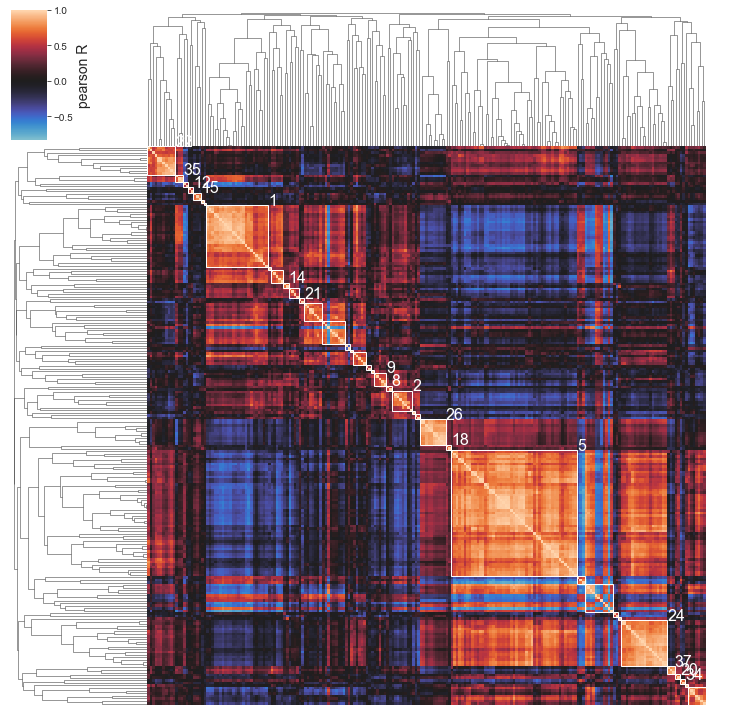

C:\Users\99hee\AppData\Local\Temp\ipykernel_16296\3943391658.py:361: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


[AgglomerativeClustering(affinity='precomputed', compute_full_tree=True,
                         distance_threshold=0.6000000000000001,
                         linkage='complete', n_clusters=None)]

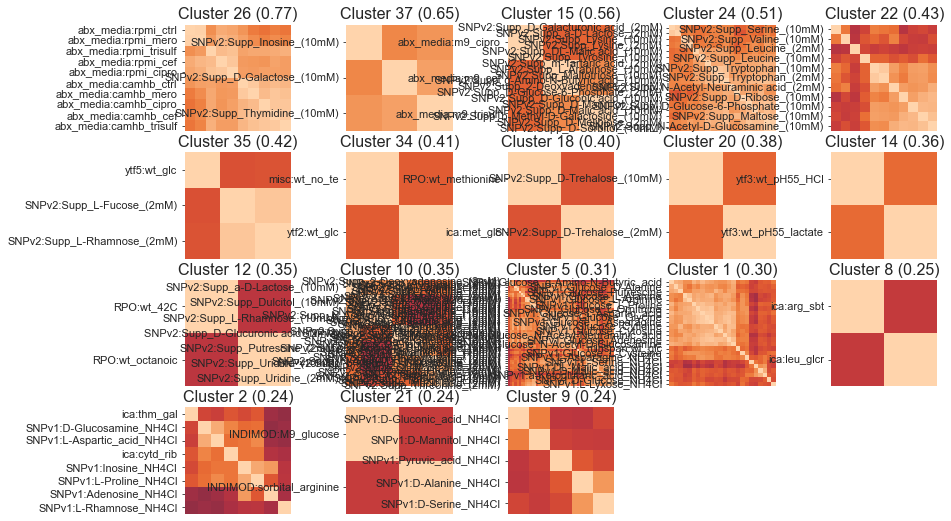

In [14]:
# clustering all samples of interest
cluster_samples(ica_data, show_best_clusters = True)

## Figure 4C-D

In [15]:
# samples in each cluster of interest
cluster_5 = ['pmg_wt_249', 'pmg_wt_250', 'pmg_wt_251', 'pmg_wt_252','pmg_wt_253', 'pmg_wt_254',
         'pmg_wt_215', 'pmg_wt_216','pmg_wt_211', 'pmg_wt_212','pmg_wt_147', 'pmg_wt_148',
         'pmg_wt_263', 'pmg_wt_264', 'pmg_wt_167', 'pmg_wt_168','pmg_wt_317', 'pmg_wt_318',
         'pmg_wt_281', 'pmg_wt_282','pmg_wt_279', 'pmg_wt_280','pmg_wt_275', 'pmg_wt_276',
         'pmg_wt_259', 'pmg_wt_260','pmg_wt_217', 'pmg_wt_218','pmg_wt_219', 'pmg_wt_220',
         'pmg_wt_225', 'pmg_wt_226','pmg_wt_183', 'pmg_wt_184','pmg_wt_227', 'pmg_wt_228',
         'pmg_wt_311', 'pmg_wt_312','pmg_wt_261', 'pmg_wt_262','pmg_wt_243', 'pmg_wt_244',
         'pmg_wt_295', 'pmg_wt_296','pmg_wt_331', 'pmg_wt_332','pmg_wt_181', 'pmg_wt_182',
         'pmg_wt_309', 'pmg_wt_310','pmg_wt_345', 'pmg_wt_346','pmg_wt_157', 'pmg_wt_158',
         'pmg_wt_283', 'pmg_wt_284','pmg_wt_339', 'pmg_wt_340','pmg_wt_291', 'pmg_wt_292',
         'pmg_wt_287', 'pmg_wt_288','pmg_wt_337', 'pmg_wt_338','pmg_wt_229', 'pmg_wt_230',
          'pmg_wt_223', 'pmg_wt_224','pmg_wt_159', 'pmg_wt_160','pmg_wt_193', 'pmg_wt_194',
         'pmg_wt_201', 'pmg_wt_202','pmg_wt_303', 'pmg_wt_304','pmg_wt_323', 'pmg_wt_324',
         'pmg_wt_205', 'pmg_wt_206','pmg_wt_307', 'pmg_wt_308','pmg_wt_203', 'pmg_wt_204',
         'pmg_wt_235', 'pmg_wt_236','pmg_wt_213', 'pmg_wt_214','pmg_wt_175', 'pmg_wt_176',
         'pmg_wt_301', 'pmg_wt_302','pmg_wt_239', 'pmg_wt_240','pmg_wt_333', 'pmg_wt_334',
         'pmg_wt_207', 'pmg_wt_208']

cluster_24 = ['pmg_wt_319', 'pmg_wt_320','pmg_wt_329', 'pmg_wt_330','pmg_wt_233', 'pmg_wt_234',
            'pmg_wt_199', 'pmg_wt_200', 'pmg_wt_171', 'pmg_wt_172','pmg_wt_245', 'pmg_wt_246',
            'pmg_wt_313', 'pmg_wt_314', 'pmg_wt_163', 'pmg_wt_164', 'pmg_wt_177', 'pmg_wt_178',
            'pmg_wt_197', 'pmg_wt_198','pmg_wt_267', 'pmg_wt_268','pmg_wt_305', 'pmg_wt_306',
            'pmg_wt_149', 'pmg_wt_150','pmg_wt_293', 'pmg_wt_294','pmg_wt_179', 'pmg_wt_180',
            'pmg_wt_185', 'pmg_wt_186','pmg_wt_299', 'pmg_wt_300','pmg_wt_347', 'pmg_wt_348']

cluster_22 = ['pmg_wt_237', 'pmg_wt_238','pmg_wt_247', 'pmg_wt_248','pmg_wt_187', 'pmg_wt_188',
                    'pmg_wt_231', 'pmg_wt_232', 'pmg_wt_241', 'pmg_wt_242', 'pmg_wt_209', 'pmg_wt_210',
                    'pmg_wt_321', 'pmg_wt_322', 'pmg_wt_153', 'pmg_wt_154', 'pmg_wt_169', 'pmg_wt_170',
                    'pmg_wt_155', 'pmg_wt_156','pmg_wt_165', 'pmg_wt_166']

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly 

<AxesSubplot: xlabel='pmg_wt_319\npmg_wt_320\npmg_wt_329\npmg_wt_330\npmg_wt_233\npmg_wt_234\npmg_wt_199\npmg_wt_200\npmg_wt_171\npmg_wt_172\npmg_wt_245\npmg_wt_246\npmg_wt_313\npmg_wt_314\npmg_wt_163\npmg_wt_164\npmg_wt_177\npmg_wt_178\npmg_wt_197\npmg_wt_198\npmg_wt_267\npmg_wt_268\npmg_wt_305\npmg_wt_306\npmg_wt_149\npmg_wt_150\npmg_wt_293\npmg_wt_294\npmg_wt_179\npmg_wt_180\npmg_wt_185\npmg_wt_186\npmg_wt_299\npmg_wt_300\npmg_wt_347\npmg_wt_348', ylabel='pmg_wt_249\npmg_wt_250\npmg_wt_251\npmg_wt_252\npmg_wt_253\npmg_wt_254\npmg_wt_215\npmg_wt_216\npmg_wt_211\npmg_wt_212\npmg_wt_147\npmg_wt_148\npmg_wt_263\npmg_wt_264\npmg_wt_167\npmg_wt_168\npmg_wt_317\npmg_wt_318\npmg_wt_281\npmg_wt_282\npmg_wt_279\npmg_wt_280\npmg_wt_275\npmg_wt_276\npmg_wt_259\npmg_wt_260\npmg_wt_217\npmg_wt_218\npmg_wt_219\npmg_wt_220\npmg_wt_225\npmg_wt_226\npmg_wt_183\npmg_wt_184\npmg_wt_227\npmg_wt_228\npmg_wt_311\npmg_wt_312\npmg_wt_261\npmg_wt_262\npmg_wt_243\npmg_wt_244\npmg_wt_295\npmg_wt_296\npmg_wt_33

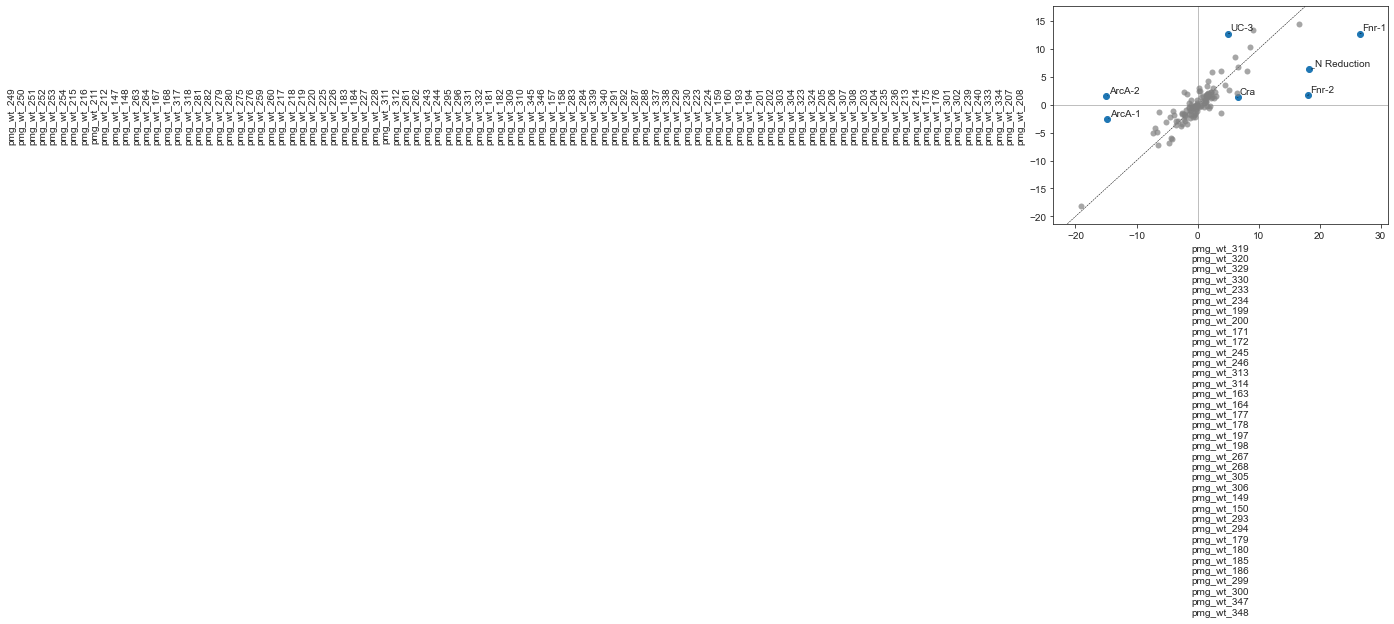

In [16]:
plot_dima(ica_data, cluster_24, cluster_5, fdr = 0.18)

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly 

<AxesSubplot: xlabel='pmg_wt_319\npmg_wt_320\npmg_wt_329\npmg_wt_330\npmg_wt_233\npmg_wt_234\npmg_wt_199\npmg_wt_200\npmg_wt_171\npmg_wt_172\npmg_wt_245\npmg_wt_246\npmg_wt_313\npmg_wt_314\npmg_wt_163\npmg_wt_164\npmg_wt_177\npmg_wt_178\npmg_wt_197\npmg_wt_198\npmg_wt_267\npmg_wt_268\npmg_wt_305\npmg_wt_306\npmg_wt_149\npmg_wt_150\npmg_wt_293\npmg_wt_294\npmg_wt_179\npmg_wt_180\npmg_wt_185\npmg_wt_186\npmg_wt_299\npmg_wt_300\npmg_wt_347\npmg_wt_348', ylabel='pmg_wt_237\npmg_wt_238\npmg_wt_247\npmg_wt_248\npmg_wt_187\npmg_wt_188\npmg_wt_231\npmg_wt_232\npmg_wt_241\npmg_wt_242\npmg_wt_209\npmg_wt_210\npmg_wt_321\npmg_wt_322\npmg_wt_153\npmg_wt_154\npmg_wt_169\npmg_wt_170\npmg_wt_155\npmg_wt_156\npmg_wt_165\npmg_wt_166'>

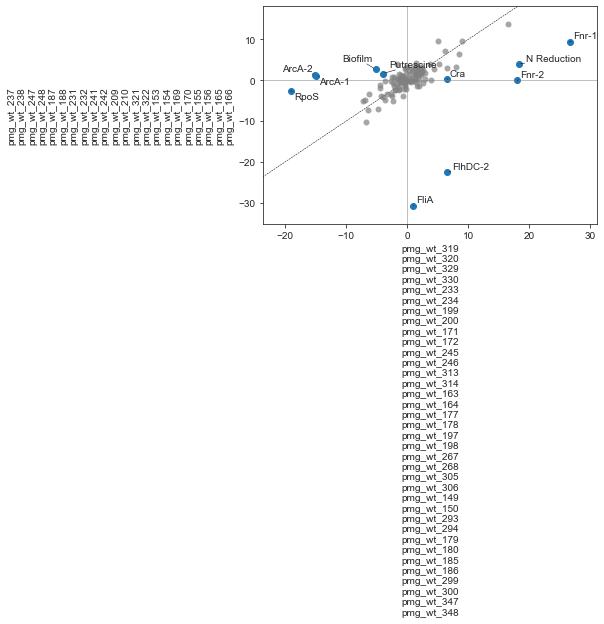

In [17]:
plot_dima(ica_data, cluster_24, cluster_22, fdr = 0.1)

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly 

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _diff[":".join(name)] = abs(A_to_use[i1] - A_to_use[i2])
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\util.py:174: PerformanceWarning: DataFrame is highly 

<AxesSubplot: xlabel='pmg_wt_249\npmg_wt_250\npmg_wt_251\npmg_wt_252\npmg_wt_253\npmg_wt_254\npmg_wt_215\npmg_wt_216\npmg_wt_211\npmg_wt_212\npmg_wt_147\npmg_wt_148\npmg_wt_263\npmg_wt_264\npmg_wt_167\npmg_wt_168\npmg_wt_317\npmg_wt_318\npmg_wt_281\npmg_wt_282\npmg_wt_279\npmg_wt_280\npmg_wt_275\npmg_wt_276\npmg_wt_259\npmg_wt_260\npmg_wt_217\npmg_wt_218\npmg_wt_219\npmg_wt_220\npmg_wt_225\npmg_wt_226\npmg_wt_183\npmg_wt_184\npmg_wt_227\npmg_wt_228\npmg_wt_311\npmg_wt_312\npmg_wt_261\npmg_wt_262\npmg_wt_243\npmg_wt_244\npmg_wt_295\npmg_wt_296\npmg_wt_331\npmg_wt_332\npmg_wt_181\npmg_wt_182\npmg_wt_309\npmg_wt_310\npmg_wt_345\npmg_wt_346\npmg_wt_157\npmg_wt_158\npmg_wt_283\npmg_wt_284\npmg_wt_339\npmg_wt_340\npmg_wt_291\npmg_wt_292\npmg_wt_287\npmg_wt_288\npmg_wt_337\npmg_wt_338\npmg_wt_229\npmg_wt_230\npmg_wt_223\npmg_wt_224\npmg_wt_159\npmg_wt_160\npmg_wt_193\npmg_wt_194\npmg_wt_201\npmg_wt_202\npmg_wt_303\npmg_wt_304\npmg_wt_323\npmg_wt_324\npmg_wt_205\npmg_wt_206\npmg_wt_307\npmg_wt

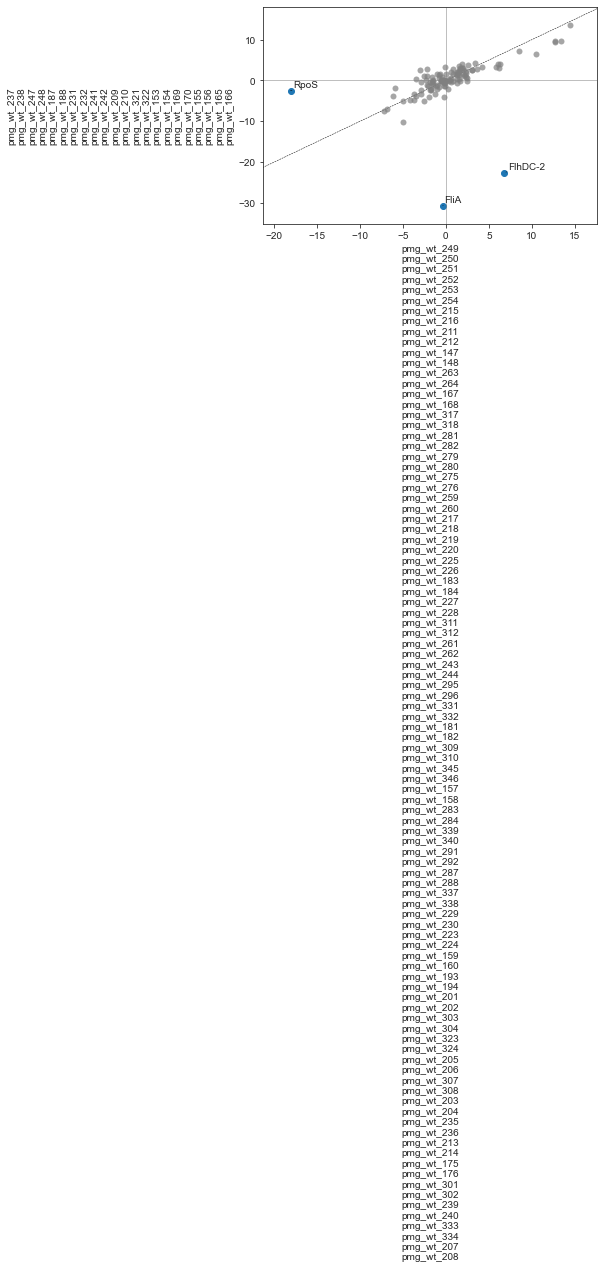

In [18]:
plot_dima(ica_data, cluster_5, cluster_22, fdr = 0.13)